In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import fsps
from jax import jit
from tqdm import tqdm
from astropy import constants as const
tiny_number = 1e-70

from ceridwen.ssps.ssp_data import SSPData
from ceridwen.csp.csp import CSPBasis, fnu2flam

T_UNIV = 13.8  # Gyr, age of the universe
N_T = 100     # number of time steps for SFH

def gaussian_burst(tau, center_tau, width_tau, amp=1.0):
    """Gaussian in lookback time, evaluated on tau grid (Gyr)."""
    return amp * jnp.exp(-0.5 * ((tau - center_tau) / width_tau)**2)

t = jnp.linspace(1e-2, T_UNIV, N_T)   # Gyr (avoid exactly 0)
tau = T_UNIV - t                      # lookback time (Gyr)

sfr_bimodal = (gaussian_burst(tau, 0.05, 0.03, 1.0) +
               gaussian_burst(tau, 11.0, 0.8, 0.7))
zh = jnp.full_like(t, 10**-4.3477116)  # constant metallicity (Z=0.02)

ssp_data = SSPData.load('/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/ssp_data.h5')

ssp_data.ssp_flux.shape




(12, 108, 5994)

In [2]:
sp = fsps.StellarPopulation(zcontinuous=3, sfh=3, add_neb_emission=False, add_neb_continuum=False)


In [3]:
sp.set_tabular_sfh(age = np.asarray(t), sfr = np.asarray(sfr_bimodal), Z=zh)
wave, spec_fsps_dustfree= sp.get_spectrum(tage=13.8) 

In [19]:
diffdust = 0.2
diffdust_index = -0.7
young_dust = 10
young_dust_index = -1

In [20]:
#-----------------------------
# FSPS with all dust
#-----------------------------

sp.params['dust1'] = young_dust
sp.params['dust2'] = diffdust
sp.params['dust1_index'] = young_dust_index
sp.params['dust_index'] = diffdust_index

sp.params['add_dust_emission'] = False
sp.params['dust_type'] = 4

wave, spec_fsps_dust = sp.get_spectrum(tage=13.8) 
print('FSPS with \ndust1:', sp.params['dust1'], '\ndust2:', sp.params['dust2'], '\ndust1_index:', sp.params['dust1_index'], '\ndust_index:', sp.params['dust_index'])


#-----------------------------
# FSPS with all dust and dust emission
#-----------------------------

sp.params['add_dust_emission'] = True
wave, spec_fsps_dust_emi = sp.get_spectrum(tage=13.8) 

#-----------------------------
# FSPS with only diffuse dust
#-----------------------------

sp.params['dust1'] = 0
sp.params['dust2'] = diffdust
sp.params['dust1_index'] = 0
sp.params['dust_index'] = diffdust_index

sp.params['add_dust_emission'] = False

wave, spec_fsps_diffuse = sp.get_spectrum(tage=13.8) 
print('FSPS with \ndust1:', sp.params['dust1'], '\ndust2:', sp.params['dust2'], '\ndust1_index:', sp.params['dust1_index'], '\ndust_index:', sp.params['dust_index'])


#-----------------------------
# FSPS with only diffuse dust and dust emission
#-----------------------------

sp.params['add_dust_emission'] = True
wave, spec_fsps_diffuse_emi = sp.get_spectrum(tage=13.8) 


#-----------------------------
# FSPS with only young dust
#-----------------------------

sp.params['dust1'] = young_dust
sp.params['dust2'] = 0
sp.params['dust1_index'] = young_dust_index
sp.params['dust_index'] = 0

sp.params['add_dust_emission'] = False

wave, spec_fsps_young = sp.get_spectrum(tage=13.8) 

#-----------------------------
# FSPS with only young dust and dust emission
#-----------------------------

sp.params['add_dust_emission'] = True
wave, spec_fsps_young_emi = sp.get_spectrum(tage=13.8) 



print('FSPS with dust emission \nduste_umin:', sp.params['duste_umin'], '\nduste_qpah:', sp.params['duste_qpah'], '\nduste_gamma:', sp.params['duste_gamma'])


FSPS with 
dust1: 10 
dust2: 0.2 
dust1_index: -1 
dust_index: -0.7
FSPS with 
dust1: 0 
dust2: 0.2 
dust1_index: 0 
dust_index: -0.7
FSPS with dust emission 
duste_umin: 1.0 
duste_qpah: 3.5 
duste_gamma: 0.01


In [21]:
csp = CSPBasis(ssp_data, theta_dict = {'lookback_time': tau, 'sfh': sfr_bimodal, 'zh': zh}, tuniv = 13.8, tiny_logt = -70, zh_const = False,
                 add_neb = False, init_neb_params = {"isoc_type": "mist", "cloudy_dust": True}, 
                 add_dust = True, add_diffuse_dust = True, add_dust_emission = False, sps_home = '/Users/amanda/Prospector/fsps',
                 init_dust_params = {'bin_edges': [(-jnp.inf, -1.97)], 
                                'laws': ['powerlaw']}, verbose = True)

def run_spectrum(csp, theta):
    return csp.get_spectrum(theta)

# --- Compile the function, marking `csp` as static
run_spectrum_jit = jit(run_spectrum, static_argnums=0)

#-------------------------------
# CSP SPECTRUM WITHOUT DUST
#-------------------------------

theta = jnp.array(csp.theta_init.at[csp.tau_pow_idx].set(0))
theta = jnp.array(theta.at[csp.alpha_idx].set(0))
theta = jnp.array(theta.at[csp.diffuse_dust_index_idx].set(0))
theta = jnp.array(theta.at[csp.diffuse_tau_kc_idx].set(0))

spec_dustfree = run_spectrum_jit(csp, theta)

#-------------------------------
# CSP SPECTRUM WITH ALL DUST
#-------------------------------

theta = jnp.array(csp.theta_init.at[csp.tau_pow_idx].set(young_dust))
theta = jnp.array(theta.at[csp.alpha_idx].set(young_dust_index))
theta = jnp.array(theta.at[csp.diffuse_dust_index_idx].set(diffdust_index))
theta = jnp.array(theta.at[csp.diffuse_tau_kc_idx].set(diffdust))

spec_dust = run_spectrum_jit(csp, theta)


#-------------------------------
# CSP SPECTRUM WITH DIFFUSE DUST ONLY
#-------------------------------

theta = jnp.array(csp.theta_init.at[csp.tau_pow_idx].set(0))
theta = jnp.array(theta.at[csp.alpha_idx].set(0))
theta = jnp.array(theta.at[csp.diffuse_dust_index_idx].set(diffdust_index))
theta = jnp.array(theta.at[csp.diffuse_tau_kc_idx].set(diffdust))

spec_diffuse = run_spectrum_jit(csp, theta)

#-------------------------------
# CSP SPECTRUM WITH Young DUST ONLY
#-------------------------------

theta = jnp.array(csp.theta_init.at[csp.tau_pow_idx].set(young_dust))
theta = jnp.array(theta.at[csp.alpha_idx].set(young_dust_index))
theta = jnp.array(theta.at[csp.diffuse_dust_index_idx].set(0))
theta = jnp.array(theta.at[csp.diffuse_tau_kc_idx].set(0))

spec_young_dust = run_spectrum_jit(csp, theta)

from pprint import pprint
pprint(csp.params)

Using combined (binwise + diffuse) dust attenuation.
Initializing Dust attenuation model...
Initializing DiffuseDust model...
Dust initialization complete.
Get spectrum with dust attenuation, without nebular contribution, and without dust emission.
dict_keys(['sfh_times', 'sfh', 'theta_init', 'alpha_idx', 'diffuse_dust_index_idx', 'diffuse_tau_kc_idx', 'sfh_idx', 'tau_pow_idx', 'zh_idx'])
{'alpha': {'length': 1, 'pos': '201'},
 'diffuse_dust_index': {'length': 1, 'pos': '203'},
 'diffuse_tau_kc': {'length': 1, 'pos': '202'},
 'sfh': {'length': 100, 'pos': '0–99'},
 'tau_pow': {'length': 1, 'pos': '200'},
 'zh': {'length': 100, 'pos': '100–199'}}


In [41]:
csp.theta_init[csp.diffuse_dust_index_idx]

Array([0.], dtype=float32)

In [33]:
print(csp.params)

{'alpha': {'pos': '201', 'length': 1}, 'diffuse_dust_index': {'pos': '203', 'length': 1}, 'diffuse_tau_kc': {'pos': '202', 'length': 1}, 'sfh': {'pos': '0–99', 'length': 100}, 'tau_pow': {'pos': '200', 'length': 1}, 'zh': {'pos': '100–199', 'length': 100}}


In [ ]:
csp_dust = CSPBasis(ssp_data, theta_dict = {'lookback_time': tau, 'sfh': sfr_bimodal, 'zh': zh}, tuniv = 13.8, tiny_logt = -70, zh_const = False,
                 add_neb = False, init_neb_params = {"isoc_type": "mist", "cloudy_dust": True}, 
                 add_dust = True, add_diffuse_dust = True, add_dust_emission = True, sps_home = '/Users/amanda/Prospector/fsps',
                 init_dust_params = {'bin_edges': [(-jnp.inf, -1.97)], 
                                'laws': ['powerlaw']}, verbose = True)


#-------------------------------
# CSP SPECTRUM WITH DIFFUSE DUST ONLY and Emission
#-------------------------------

theta = jnp.array(csp_dust.theta_init.at[csp_dust.tau_pow_idx].set(0))
theta = jnp.array(theta.at[csp_dust.alpha_idx].set(0))
theta = jnp.array(theta.at[csp_dust.diffuse_dust_index_idx].set(diffdust_index))
theta = jnp.array(theta.at[csp_dust.diffuse_tau_kc_idx].set(diffdust))

spec_diffuse_csp_emi = run_spectrum_jit(csp_dust, theta)

#-------------------------------
# CSP SPECTRUM WITH YOUNG DUST ONLY and Emission
#-------------------------------

theta = jnp.array(csp_dust.theta_init.at[csp_dust.tau_pow_idx].set(young_dust))
theta = jnp.array(theta.at[csp_dust.alpha_idx].set(young_dust_index))
theta = jnp.array(theta.at[csp_dust.diffuse_dust_index_idx].set(0))
theta = jnp.array(theta.at[csp_dust.diffuse_tau_kc_idx].set(0))

spec_young_csp_emi = run_spectrum_jit(csp_dust, theta)
#-------------------------------
# CSP SPECTRUM WITH ALL DUST and Emission
#-------------------------------

theta = jnp.array(csp_dust.theta_init.at[csp_dust.tau_pow_idx].set(young_dust))
theta = jnp.array(theta.at[csp_dust.alpha_idx].set(young_dust_index))
theta = jnp.array(theta.at[csp_dust.diffuse_dust_index_idx].set(diffdust_index))
theta = jnp.array(theta.at[csp_dust.diffuse_tau_kc_idx].set(diffdust))

spec_dust_csp_emi = run_spectrum_jit(csp_dust, theta)

Using combined (binwise + diffuse) dust attenuation.
Initializing Dust attenuation model...
Initializing DiffuseDust model...
Initializing DustEmission model...
Dust initialization complete.
Get spectrum with dust attenuation, without nebular contribution, and with dust emission.
dict_keys(['sfh_times', 'sfh', 'theta_init', 'alpha_idx', 'diffuse_dust_index_idx', 'diffuse_tau_kc_idx', 'duste_gamma_idx', 'duste_qpah_idx', 'duste_umin_idx', 'sfh_idx', 'tau_pow_idx', 'zh_idx'])


In [44]:
csp_dust.params

{'alpha': {'pos': '201', 'length': 1},
 'diffuse_dust_index': {'pos': '203', 'length': 1},
 'diffuse_tau_kc': {'pos': '202', 'length': 1},
 'duste_gamma': {'pos': '206', 'length': 1},
 'duste_qpah': {'pos': '204', 'length': 1},
 'duste_umin': {'pos': '205', 'length': 1},
 'sfh': {'pos': '0–99', 'length': 100},
 'tau_pow': {'pos': '200', 'length': 1},
 'zh': {'pos': '100–199', 'length': 100}}

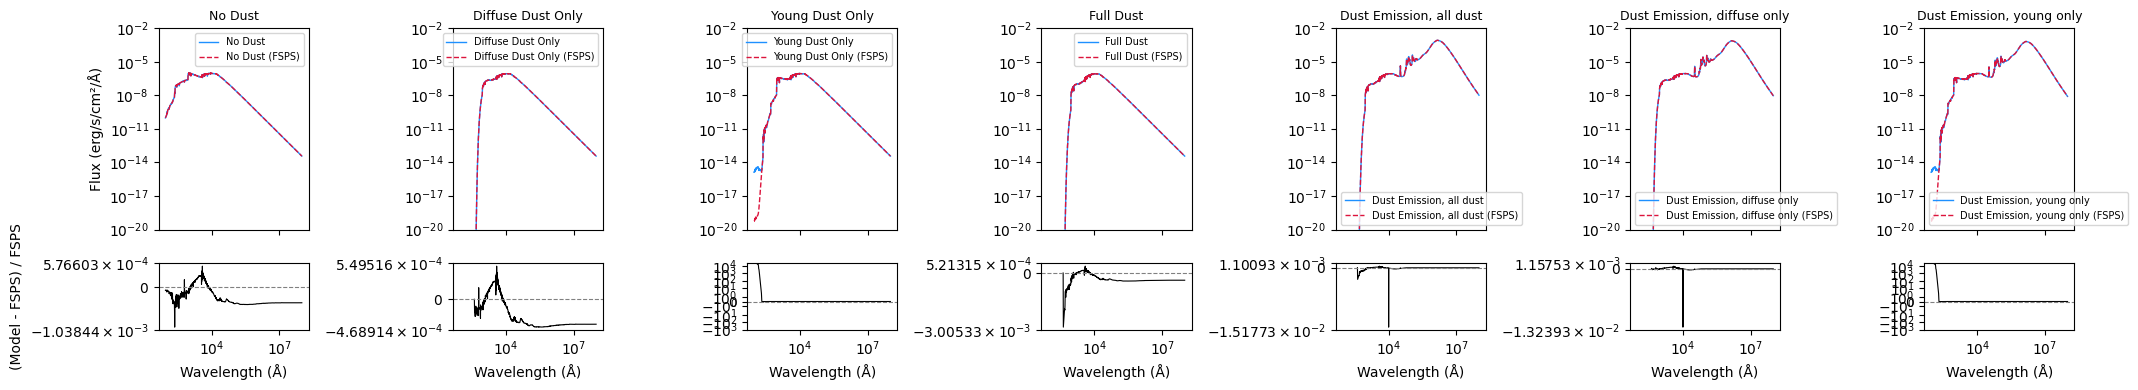

In [23]:
fig, axes = plt.subplots(2, 7, figsize=(21, 4), sharex='col', gridspec_kw={'height_ratios': [3, 1]})

# --- Data ---
waves = csp.wave
cases = [
    ('No Dust', spec_dustfree, spec_fsps_dustfree, 'dodgerblue', 'crimson'),
    ('Diffuse Dust Only', spec_diffuse, spec_fsps_diffuse, 'dodgerblue', 'crimson'),
    ('Young Dust Only', spec_young_dust, spec_fsps_young, 'dodgerblue', 'crimson'),
    ('Full Dust', spec_dust, spec_fsps_dust, 'dodgerblue', 'crimson'),
    ('Dust Emission, all dust', spec_dust_csp_emi, spec_fsps_dust_emi, 'dodgerblue', 'crimson'),
    ('Dust Emission, diffuse only', spec_diffuse_csp_emi, spec_fsps_diffuse_emi, 'dodgerblue', 'crimson'),
    ('Dust Emission, young only', spec_young_csp_emi, spec_fsps_young_emi, 'dodgerblue', 'crimson')
]

# --- Main spectra (top row) ---
for i, (label, model, fsps, color1, color2) in enumerate(cases):
    ax = axes[0, i]
    ax.loglog(waves, model, color=color1, lw=1, label=f'{label}')
    ax.loglog(waves, fsps, color=color2, lw=1, ls = '--', label=f'{label} (FSPS)')
    ax.set_ylim(1e-20, 1e-2)
    if i == 0:
        ax.set_ylabel('Flux (erg/s/cm²/Å)')
    ax.legend(fontsize=7)
    ax.set_title(label, fontsize=9)

# --- Normalized residuals (bottom row) ---
for i, (label, model, fsps, _, _) in enumerate(cases):
    axr = axes[1, i]

    resid = (model - fsps) / fsps
    axr.semilogx(waves, resid, color='k', lw=0.8)
    axr.axhline(0, color='gray', ls='--', lw=0.8)
    axr.set_yscale('symlog')
    axr.set_xlabel('Wavelength (Å)')
    if i == 0:
        axr.set_ylabel('(Model - FSPS) / FSPS')
    #axr.set_ylim(-0.005, 0.005)


plt.tight_layout()


# Is the difference problematic?

In [27]:
clight = const.c.value  # m/s
tiny_number = 1e-70

nu = clight * 1e10 / wave  # Hz

# --- Compute Lbol before and after attenuation ---
Acsp = jnp.trapezoid(spec_young_dust, nu)
Afsps = jnp.trapezoid(spec_fsps_young, nu)

print((Acsp - Afsps)/Afsps)

-5.65776e-05


In [29]:
# --- Compute Lbol before and after attenuation ---
Acsp = jnp.trapezoid(spec_young_csp_emi, nu)
Afsps = jnp.trapezoid(spec_fsps_young_emi, nu)

print((Acsp - Afsps)/Afsps)

-3.8951875e-05


In [30]:
# --- Compute Lbol before and after attenuation ---
Acsp = jnp.trapezoid(spec_dustfree, nu)
Afsps = jnp.trapezoid(spec_fsps_dustfree, nu)

print((Acsp - Afsps)/Afsps)

-3.916281e-05


In [32]:
# --- Compute Lbol before and after attenuation ---
Acsp = jnp.trapezoid(spec_diffuse, nu)
Afsps = jnp.trapezoid(spec_fsps_diffuse, nu)

print((Acsp - Afsps)/Afsps)

6.14186e-05
